In [18]:
# Import Python libraries to work with SciServer
import SciServer.CasJobs as CasJobs # query with CasJobs
import SciServer.SkyServer as SkyServer # look up objects and generate images
print('SciServer libraries imported')

SciServer libraries imported


In [19]:
# Import some other needed libraries
import pandas
import numpy as np
from scipy import stats
from matplotlib import pyplot as plt
print('Other libraries imported')

Other libraries imported


In [20]:
# Apply some settings

# ensure columns get written completely in notebook
pandas.set_option('display.max_colwidth', -1)
# do *not* show python warnings 
import warnings
warnings.filterwarnings('ignore')
print('Settings applied')

Settings applied


In [21]:
## Create a query to fetch stars for one of the following globular clusters
# Pal 3: RA = 151.3801, Dec = +0.072
# Pal 5: RA = 229.0128, Dec = -0.1082 

# Enter the coordinates of your star cluster (to be used to construct the query)
cluster_name = 'M13'
cluster_ra = 250.423475  # RA of the center of the cluster (in decimal degrees)
cluster_dec = +36.461319   # Dec of the center of the cluster (in decimal degrees)
cluster_radius =  18  # Radius of the cluster, in arcminutes
#cluster_distance = 23000 # approximate distance to your cluster, in units of parsecs. *** NOT USED ***

query = 'SELECT p.objid, p.psfMag_u AS u, p.psfMagErr_u as u_err, p.psfMag_g AS g, p.psfMagErr_g as g_err, '
#query = 'SELECT p.objid, p.dered_u AS u, p.psfMagErr_u as u_err, p.dered_g AS g, p.psfMagErr_g as g_err, ' # de-reddened mags
query += 'p.dered_r AS r, p.psfMagErr_r as r_err, p.dered_i AS i, p.psfMagErr_i as i_err, '
query += 'p.dered_z AS z, p.psfMagErr_z as z_err '
query += 'FROM photoObj p '
query += 'JOIN dbo.fGetNearbyObjEq(' + str(cluster_ra) + ', ' + str(cluster_dec) + ', ' + str(cluster_radius) + ') n '
query += 'ON p.objid = n.objID '
query += 'WHERE p.type = 6 '
query += 'AND p.psfMag_g BETWEEN -10 AND 23 '
query += 'AND p.psfMag_u/p.psfMagerr_u > 30 '
query += 'AND p.psfMag_g/p.psfMagerr_g > 30 '
query += 'AND p.psfMag_r/p.psfMagerr_r > 30 '
query += 'AND p.psfMag_i/p.psfMagerr_i > 30 '
query += 'AND p.psfMag_z/p.psfMagerr_z > 30'
#print(query)   # useful for debugging, remove first # to uncomment

# send query to CasJobs
stars = CasJobs.executeQuery(query, "dr16")

print(len(stars))

3204


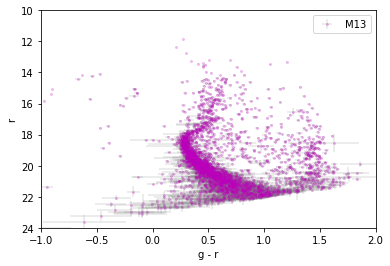

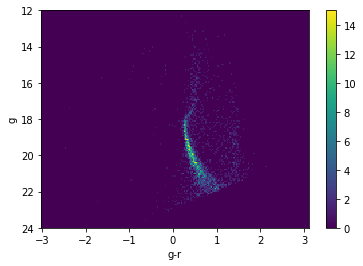

In [22]:
color = stars['g']-stars['r']
color_err = np.sqrt((stars['g_err']**2) + (stars['r_err']**2))


#plt.scatter(color,stars['r'], alpha=0.1)

#fig, ax = plt.subplots()
#ax.errorbar(x, y, xerr=0.2, yerr=0.4)
#plt.show()
#plt.figure(figsize=(9,6))
#plt.errorbar(color, stars['r'].values, yerr = color_err, xerr=stars['r_err'].values, 
#             fmt='mo', alpha=0.2, label=cluster_name)
plt.errorbar(color, stars['r'].values, yerr = color_err, xerr=stars['r_err'].values, 
             fmt='mo', alpha=0.2, label=cluster_name, markersize=2, ecolor='0.5')

plt.axis([-1,2,24,10])
plt.legend(numpoints=1)
plt.xlabel('g - r')
plt.ylabel('r')
plt.show()

plt.hist2d(color, stars['r'].values, bins=200)
plt.colorbar()
#plt.title('Color-Magnitude relation for SDSS Galaxies')
plt.xlabel('g-r')
plt.ylabel('g')
plt.ylim(24,12)
plt.show()

In [9]:
## Provide the name of your isochrone model file below:

#isofile = "isochrones/tmp1487212885.iso"  # [Fe/H]=-2.0
isofile = "isochrones/zm2_a0.iso" # [Fe/H]=-2.0, [alpha/Fe]=0

In [23]:
## Prepared for you below is a function that will 
## read in the models from your uploaded isochrone file.
def read_isofile(filename, stellar_age = 11.0):

    # Every 0.5 Gyr from 5 Gyr to 15 Gyr
    # Every 0.25 Gyr from 1 Gyr to 5 Gyr
    # Set a minimum and maximum age range (in Gyrs) below:
    #minage = minage
    #maxage = maxage
    stellar_age = stellar_age
    sdss_u = []
    sdss_g = []
    sdss_r = []
    sdss_i = []
    sdss_z = []

    age = [] # in Gigayears
    mass = [] # ratio of stellar mass to M_sun
    logT = [] # log of the effective Temperature (K)
    logL = [] # log of the ratio of stellar luminosity to L_sun
    counter=0
    for line in open(filename).readlines():
        counter+=1
        cols = line.split()
        if (line.startswith('#')):
    #        print(counter, ': starts with hashtag: ',cols)
            if (counter >= 8):   # real data starts on line #8
                if ("AGE" in cols[0]):
                    block = (line[0:11])
                    thisage = float(block.split('=')[1])
    #                print("Reading stellar models with age: {0:.2f} Gyr".format(thisage))            
        else:
            #if (thisage > minage) and (thisage < maxage):
            if thisage == stellar_age:
#                print(cols)
                if (len(cols) > 0):
                    age.append(thisage)
                    mass.append(float(cols[1]))
                    logT.append(float(cols[2]))
                    logL.append(float(cols[4]))
                    sdss_u.append(float(cols[5]))
                    sdss_g.append(float(cols[6]))
                    sdss_r.append(float(cols[7]))
                    sdss_i.append(float(cols[8]))
                    sdss_z.append(float(cols[9]))
    return (sdss_u, sdss_g, sdss_r, sdss_i, sdss_z, age, mass, logT, logL)    

(sdss_u, sdss_g, sdss_r, sdss_i, sdss_z, age, mass, logT, logL) = read_isofile(isofile)
#(sdss_u2, sdss_g2, sdss_r2, sdss_i2, sdss_z2, age2, mass2, logT2, logL2) = read_isofile(isofile2)
#(sdss_u3, sdss_g3, sdss_r3, sdss_i3, sdss_z3, age3, mass3, logT3, logL3) = read_isofile(isofile3)
print("Read in {0:.0f} stellar models, age {1:.2f} Gyr.".format(len(sdss_u), age[0]))

Read in 267 stellar models, age 11.00 Gyr.


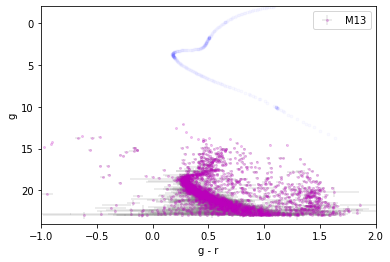

In [24]:
model_color = np.array(sdss_g)-np.array(sdss_r)
model_g = np.array(sdss_g)
#model_color2 = np.array(sdss_g2)-np.array(sdss_r2)
#model_g2 = np.array(sdss_g2)
#model_color3 = np.array(sdss_g3)-np.array(sdss_r3)
#model_g3 = np.array(sdss_g3)

#plt.scatter(color,stars['r'], alpha=0.1)
plt.errorbar(color, stars['g'], yerr = color_err, xerr=stars['r_err'], fmt='mo', 
             alpha=0.2, label=cluster_name, markersize=2, ecolor='0.5')
plt.axis([-1,2,24,-2])
plt.legend(numpoints=1)
plt.xlabel('g - r')
plt.ylabel('g')
plt.plot(model_color,model_g, 'b.', alpha=0.02)
#plt.plot(model_color2,model_g2, 'b.', alpha=0.02)
#plt.plot(model_color3,model_g3, 'b.', alpha=0.02)

plt.show()

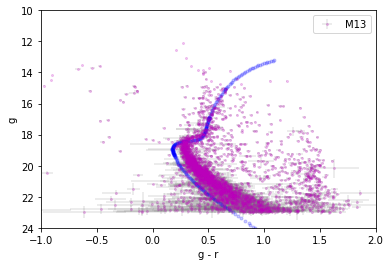

In [25]:
from math import log10

## approximate distance to NGC 2420 in units of parsecs (may have been set when retrieving data)
cluster_distance = 11000

dm = 5*log10(cluster_distance/10)

model_g_corr = model_g+dm

plt.errorbar(color, stars['g'], yerr = color_err, xerr=stars['r_err'], fmt='mo', alpha=0.2, 
             label=cluster_name, markersize=2, ecolor='0.5')
plt.axis([-1,2,24,10])
plt.legend(numpoints=1)
plt.xlabel('g - r')
plt.ylabel('g')
plt.plot(model_color,model_g_corr, 'b.', alpha=0.2)
plt.show()

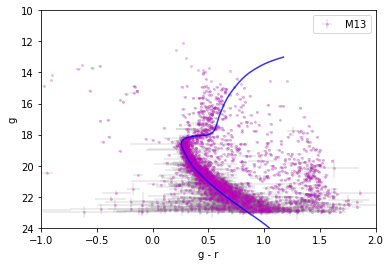

In [26]:
# All free parameters 
# 

age = 10
iso = 'zm2_a0'
isofile = "isochrones/" + iso + ".iso"
(sdss_u, sdss_g, sdss_r, sdss_i, sdss_z, age, mass, logT, logL) = read_isofile(isofile, stellar_age = age)

model_g = np.array(sdss_g)
model_color = np.array(sdss_g)-np.array(sdss_r)

# set ebv below
#ebv = 0.1
#av = 3.2*ebv
egr = 0.1
ag = 3.64*egr

# set distance
cluster_distance = 8500
dm = 5*log10(cluster_distance/10)
model_g_corr = model_g+dm

model_g_dered = np.array(model_g_corr) + ag
model_gr_dered = np.array(model_color) + egr

#plt.figure(figsize=(12,8))
plt.errorbar(color, stars['g'], yerr = color_err, xerr=stars['r_err'], fmt='mo', 
             alpha=0.2, label=cluster_name, markersize=2, ecolor='0.5')

plt.axis([-1,2,24,10])
plt.legend(numpoints=1)
plt.xlabel('g - r')
plt.ylabel('g')
plt.plot(model_gr_dered,model_g_dered, color='b', alpha=0.8, zorder=10)
plt.show()

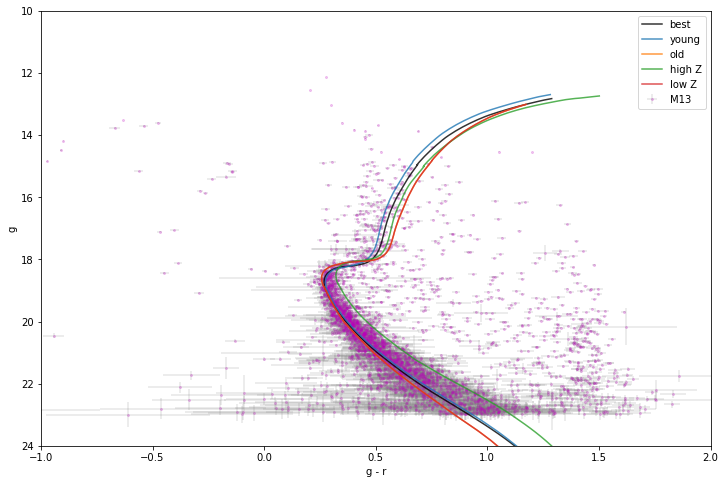

In [27]:
# Plot many models all at once.

ages = [13, 15, 10, 15, 10]
zz = ['zm15_a0', 'zm15_a0', 'zm2_a0', 'zm1_a0', 'zm2_a0']
egrs = [ 0.02, 0, 0.1, 0, 0.1 ]
d = [8000, 7700, 8500, 6500, 8500]
labels = ['best', 'young', 'old', 'high Z', 'low Z']
cc = ['k', 'C0', 'C1', 'C2', 'C3']

"""
age = 10
iso = 'zm2_a0'
isofile = "isochrones/" + iso + ".iso"
(sdss_u, sdss_g, sdss_r, sdss_i, sdss_z, age, mass, logT, logL) = read_isofile(isofile, stellar_age=age)

model_g = np.array(sdss_g)
model_color = np.array(sdss_g)-np.array(sdss_r)

# set ebv below
#ebv = 0.1
#av = 3.2*ebv
egr = 0.1
ag = 3.64*egr

# set distance
cluster_distance = 8500
dm = 5*log10(cluster_distance/10)
model_g_corr = model_g+dm

model_g_dered = np.array(model_g_corr) + ag
model_gr_dered = np.array(model_color) + egr
"""

plt.figure(figsize=(12,8))
plt.errorbar(color, stars['g'], yerr = color_err, xerr=stars['r_err'], fmt='mo', 
             alpha=0.2, label=cluster_name, markersize=2, ecolor='0.5')
plt.axis([-1,2,24,10])

for i in range(5):
    age = ages[i]
    isofile = "isochrones/" + zz[i] + ".iso"
    (sdss_u, sdss_g, sdss_r, sdss_i, sdss_z, age, mass, logT, logL) = read_isofile(isofile, stellar_age=age)
    model_g = np.array(sdss_g)
    model_color = np.array(sdss_g)-np.array(sdss_r)
    
    egr = egrs[i]
    ag = 3.64*egr
    
    dm = 5*log10(d[i]/10)
    model_g_corr = model_g+dm

    model_g_dered = np.array(model_g_corr) + ag
    model_gr_dered = np.array(model_color) + egr


    plt.plot(model_gr_dered,model_g_dered, color=cc[i], alpha=0.8, zorder=10, label=labels[i])

plt.legend(numpoints=1)
plt.xlabel('g - r')
plt.ylabel('g')    
plt.show()

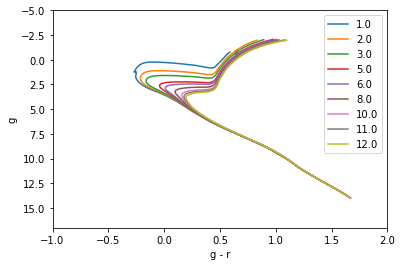

In [28]:
for age in [1.0, 2.0, 3.0, 5.0, 6.0, 8.0, 10.0, 11.0, 12.0]:
    (sdss_u, sdss_g, sdss_r, sdss_i, sdss_z, age, mass, logT, logL) = read_isofile(isofile, stellar_age=age)
    model_color = np.array(sdss_g)-np.array(sdss_r)
    model_g = np.array(sdss_g)
    #plt.errorbar(color, stars['g'], yerr = color_err, xerr=stars['r_err'], fmt='mo', alpha=0.2, label=cluster_name)
    plt.axis([-1,2,17,-5])
    plt.plot(model_color,model_g, label='{:.1f}'.format(float(age[0])) )
    plt.legend(numpoints=1)
    plt.xlabel('g - r')
    plt.ylabel('g')
    

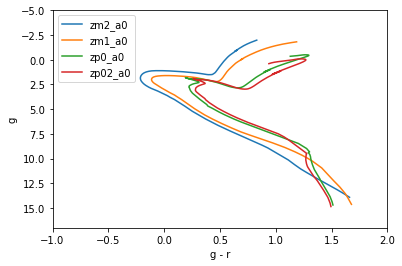

In [29]:
for iso in ['zm2_a0','zm1_a0','zp0_a0', 'zp02_a0']:
    age = 2.0
    isofile = "isochrones/" + iso + ".iso"
    (sdss_u, sdss_g, sdss_r, sdss_i, sdss_z, age, mass, logT, logL) = read_isofile(isofile, stellar_age=age)
    model_color = np.array(sdss_g)-np.array(sdss_r)
    model_g = np.array(sdss_g)
    #plt.errorbar(color, stars['g'], yerr = color_err, xerr=stars['r_err'], fmt='mo', alpha=0.2, label=cluster_name)
    plt.axis([-1,2,17,-5])
    plt.plot(model_color,model_g, label='{}'.format(iso) )
    plt.legend(numpoints=1)
    plt.xlabel('g - r')
    plt.ylabel('g')
plt.savefig('Z_iso.png')

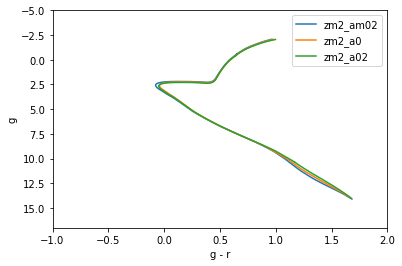

In [31]:
"""
# Ignore this one. This is for different [alpha/Fe] ratios. 
# I don't upload these models. 

for iso in ['zm2_am02','zm2_a0','zm2_a02']:
    age = 5.0
    isofile = "isochrones/" + iso + ".iso"
    (sdss_u, sdss_g, sdss_r, sdss_i, sdss_z, age, mass, logT, logL) = read_isofile(isofile, stellar_age=age)
    model_color = np.array(sdss_g)-np.array(sdss_r)
    model_g = np.array(sdss_g)
    #plt.errorbar(color, stars['g'], yerr = color_err, xerr=stars['r_err'], fmt='mo', alpha=0.2, label=cluster_name)
    plt.axis([-1,2,17,-5])
    plt.plot(model_color,model_g, label='{}'.format(iso) )
    plt.legend(numpoints=1)
    plt.xlabel('g - r')
    plt.ylabel('g')
"""